In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
dataset_path = "cifar10_bs64_dim96_head32_layer1_recur12_multiplier1.pth"
dataset = torch.load(dataset_path, weights_only=True)

In [3]:
recur = "12"
data_recur = dataset[recur]
print(data_recur["x_inter"].shape)

torch.Size([1000, 32, 12, 196, 3])


In [4]:
x_inter = data_recur["x_inter"][:, -1][11]
print(x_inter.shape)

torch.Size([12, 196, 3])


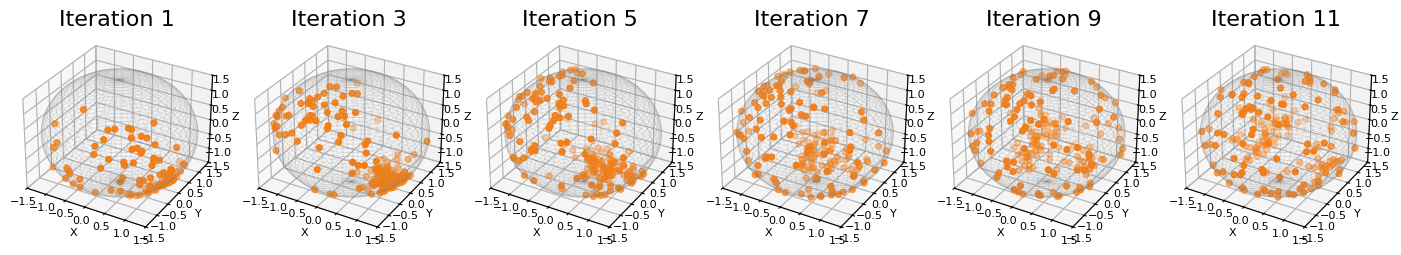

In [5]:
fig, ax = plt.subplots(1, 6, figsize=(14, 10), subplot_kw={"projection": "3d"})  # neurips
ax = ax.flatten()
plt.rc("text", usetex=True)
plt.rc("font", family="times")
plt.rc("text.latex", preamble=r"\usepackage{mathptmx}")
import math
import numpy as np

# Generating data for a spherical surface
theta = np.linspace(0, 2 * np.pi, 50)
phi = np.linspace(0, np.pi, 50)
theta, phi = np.meshgrid(theta, phi)
r = math.sqrt(x_inter.shape[-1])
x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)
for it, iteration in enumerate(range(0, 12, 2)):
    scatter_data = x_inter[iteration]
    # Plot wireframe with custom color and line style
    ax[it].plot_wireframe(x, y, z, linewidth=0.5, alpha=0.2, color="gray")

    # Scatter plot with custom color, size, and transparency
    ax[it].scatter(scatter_data[:, 0], scatter_data[:, 1], scatter_data[:, 2], s=18, c="#ff7f0e")

    # Set axis limits for better visualization
    ax[it].set_xlim([-1.5, 1.5])
    ax[it].set_ylim([-1.5, 1.5])
    ax[it].set_zlim([-1.5, 1.5])

    ax[it].grid(True, linestyle="--", alpha=0.5)
    ax[it].set_xlabel("X", fontsize=8, labelpad=-8)
    ax[it].set_ylabel("Y", fontsize=8, labelpad=-8)
    ax[it].set_zlabel("Z", fontsize=8, labelpad=-10)
    ax[it].tick_params(axis="both", which="major", labelsize=8, pad=-4)  # Reduce tick label size and padding
    ax[it].tick_params(axis="both", which="minor", labelsize=8, pad=-4)  # Adjust minor ticks if needed
    # Set title for each subplot
    ax[it].set_title(f"Iteration {iteration + 1}", fontsize=16, pad=-9)
fig.patch.set_facecolor("white")
plt.tight_layout(w_pad=1.5)
# plt.savefig("dynamics_on_hypersphere_flatten.pdf", bbox_inches="tight", dpi=300)
plt.show()